# OpenScope's Loop Dataset

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.


Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

Your_figure_here.png

You_other_figure_here.png



### Environment Setup
⚠️**Note: If running on a new environment, run this cell once and then restart the kernel**⚠️

In [45]:
import sys
from pathlib import Path

# Use the current working directory (where Jupyter thinks it started)
project_root = Path.cwd().parent.parent  # adjust if your notebook is in a subfolder
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from databook_utils.dandi_utils import dandi_download_open

In [46]:
# import warnings
# warnings.filterwarnings('ignore')

# try:
#     from databook_utils.dandi_utils import dandi_download_open
# except:
#     !git clone https://github.com/AllenInstitute/openscope_databook.git
#     %cd openscope_databook
#     %pip install -e .
#     %cd docs/projects

In [47]:
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from math import floor, ceil, isclose
from PIL import Image

### The Experiment
As shown in the metadata table below, Openscope's Loop Experiment has produced 14 main files on the [DANDI Archive](http://dandiarchive.org), with 6 males and 8 females which all have wildtype genotypes. This table was generated from [Getting Experimental Metadata from DANDI](../basics/get_dandiset_metadata.ipynb).

In [48]:
session_files = pd.read_csv("../../data/loop_sessions.csv")
session_files

,Unnamed: 0,identifier,size,path,session_time,sub_name,sub_sex,sub_age,sub_genotype,probes,stim types,#_units,session_length
0,0,8d825a76-3889-4c22-89c8-d88d4f3197b8,10895734616,sub-747825/sub-747825_ecephys.nwb,2024-08-28 14:09:58-07:00,NaN,M,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie28_presentations', 'movie02_presentatio...",3307,7471.241537
1,1,aa6720c1-249b-4f0b-a4c7-64c195cb9c03,14634262431,sub-751596/sub-751596_ecephys.nwb,2024-09-18 14:05:53-07:00,NaN,F,NaN,wt/wt,"{'probeE', 'probeB', 'Device', 'probeF', 'prob...","{'movie52_presentations', 'movie02_presentatio...",3224,7436.762007
2,2,5ed38e12-6988-4051-a8ed-305151bd5e1f,18199508740,sub-747815/sub-747815_ecephys.nwb,2024-08-13 13:50:36-07:00,NaN,M,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie28_presentations', 'movie02_presentatio...",3994,7511.931626
3,3,4f384e20-e10b-4d1e-8a71-61bfe2096b6a,16123214712,sub-754603/sub-754603_ecephys.nwb,2024-10-02 13:55:49-07:00,NaN,M,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie52_presentations', 'movie02_presentatio...",3023,7434.680925
4,4,ef66641c-e9c4-463e-a44a-83a0b9330dc7,17624059652,sub-747829/sub-747829_ecephys.nwb,2024-09-04 14:06:07-07:00,NaN,F,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie28_presentations', 'movie02_presentatio...",3787,7477.819270
5,5,f3acee7f-3142-4326-84e1-d39aa208d7da,17544195054,sub-754604/sub-754604_ecephys.nwb,2024-10-03 13:17:45-07:00,NaN,F,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie52_presentations', 'movie02_presentatio...",3935,7437.016009
6,6,461f861c-94d0-4900-b7ee-8d2bb9722701,16428913247,sub-757088/sub-757088_ecephys.nwb,2024-10-16 14:40:58-07:00,NaN,F,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie28_presentations', 'movie02_presentatio...",3057,7474.789384
7,7,d091821f-ea4e-4f53-9f43-d6ba292180f4,17355423965,sub-753020/sub-753020_ecephys.nwb,2024-09-25 13:47:49-07:00,NaN,F,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie52_presentations', 'movie02_presentatio...",3736,7436.375489
8,8,7c6b02f2-eb14-4f55-9a74-87c5b58303d6,17540793845,sub-755830/sub-755830_ecephys.nwb,2024-10-10 14:05:36-07:00,NaN,F,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie52_presentations', 'movie02_presentatio...",3805,7435.844766
9,9,9332fc65-f3d4-46b3-a6e4-c10695869f74,17401703819,sub-755828/sub-755828_ecephys.nwb,2024-10-17 13:36:40-07:00,NaN,M,NaN,wt/wt,"{'probeE', 'probeB', 'probeA', 'Device', 'prob...","{'movie28_presentations', 'movie02_presentatio...",3704,7467.368049


In [49]:
m_count = len(session_files["sub_sex"][session_files["sub_sex"] == "M"])
f_count = len(session_files["sub_sex"][session_files["sub_sex"] == "F"])
sst_count = len(session_files[session_files["sub_genotype"].str.count("Sst") >= 1])
pval_count = len(session_files[session_files["sub_genotype"].str.count("Pval") >= 1])
wt_count = len(session_files[session_files["sub_genotype"].str.count("wt/wt") >= 1])

print("Dandiset Overview:")
print(len(session_files), "files")
print(len(set(session_files["sub_name"])), "subjects", m_count, "males,", f_count, "females")
print(sst_count, "sst,", pval_count, "pval,", wt_count, "wt")

Dandiset Overview:
14 files
14 subjects 6 males, 8 females
0 sst, 0 pval, 14 wt


### Downloading Ecephys Files

In [50]:
dandiset_id = "001191"
dandi_filepath = "sub-757088/sub-757088_ecephys.nwb"
download_loc = "."
dandi_api_key = os.environ["DANDI_API_KEY"]

In [51]:
# This can sometimes take a while depending on the size of the file
io = dandi_download_open(dandiset_id, dandi_filepath, download_loc, dandi_api_key=dandi_api_key)
nwb = io.read()

File already exists
Opening file


c:\Users\carter.peene\Desktop\Repos\openscope_databook\temp-env\lib\site-packages\hdmf\common\table.py:525: UserWarning: An attribute 'name' already exists on DynamicTable 'corneal_reflection' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
c:\Users\carter.peene\Desktop\Repos\openscope_databook\temp-env\lib\site-packages\hdmf\common\table.py:525: UserWarning: An attribute 'name' already exists on DynamicTable 'ellipse' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
c:\Users\carter.peene\Desktop\Repos\openscope_databook\temp-env\lib\site-packages\hdmf\common\table.py:525: UserWarning: An attribute 'name' already exists on DynamicTable 'pupil' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g

### Showing Probe Tracks
The images below were rendered using the [Visualizing Neuropixels Probe Locations](../visualization/visualize_neuropixels_probes.ipynb) notebook. The probes are using the [Common Coordinate Framework](https://community.brain-map.org/t/allen-mouse-ccf-accessing-and-using-related-data-and-tools/359) (CCF). The experiment uses six probes labeled A-F to target various regions.

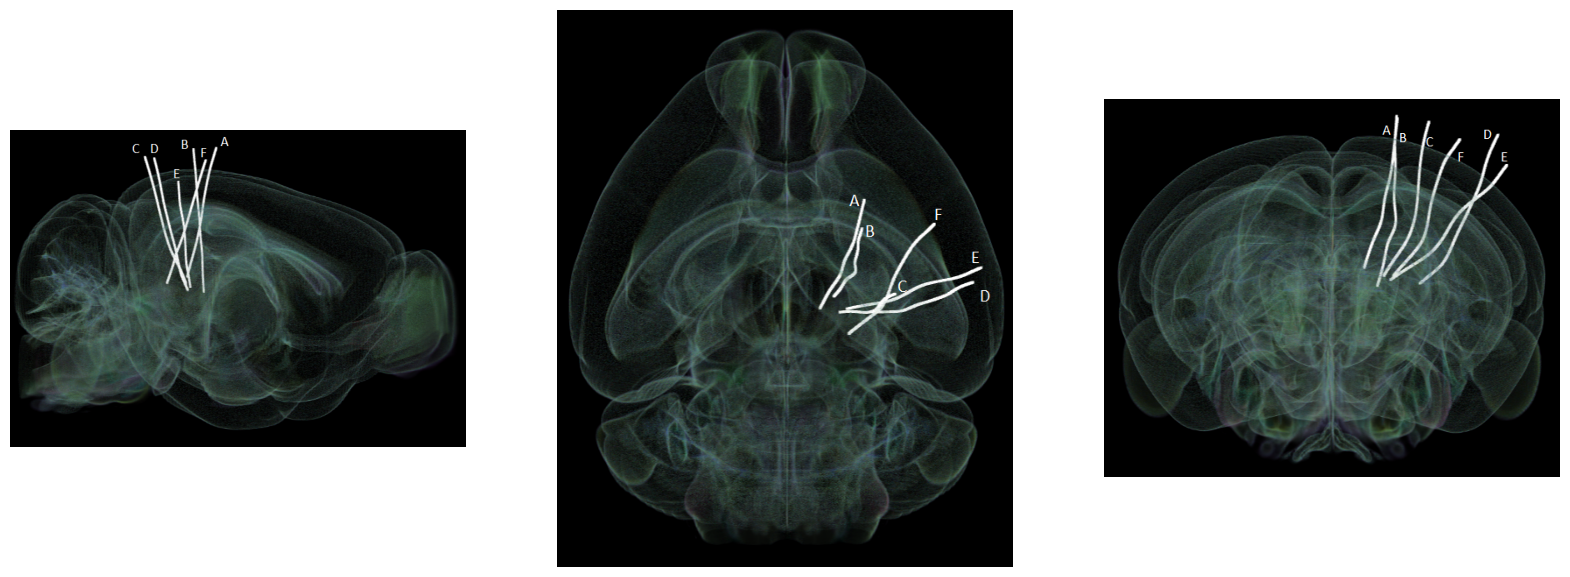

In [52]:
sagittal_view = Image.open("../../data/images/probes_sagittal.png")
dorsal_view = Image.open("../../data/images/probes_dorsal.png")
transverse_view = Image.open("../../data/images/probes_transverse.png")
fig, axes = plt.subplots(1,3,figsize=(20,60))

axes[0].imshow(sagittal_view)
axes[1].imshow(dorsal_view)
axes[2].imshow(transverse_view)
for ax in axes:
    ax.axis("off")

### Extracting Units Spikes
Below, the `Units` table is retrieved from the file. It contains many metrics for every putative neuronal unit, printed below. For the analysis in this notebook, we are only interested in the `spike_times` attribute. This is an array of timestamps that a spike is measured for each unit. For more information on the various unit metrics, see [Visualizing Unit Quality Metrics](../visualization/visualize_unit_metrics.ipynb).

In [53]:
units = nwb.units.to_dataframe()
units[:10]

,spike_times,electrodes,waveform_mean,waveform_sd,unit_name,shank,half_width,repolarization_slope,num_spikes,num_positive_peaks,...,sync_spike_8,firing_rate,drift_mad,velocity_below,amplitude,ks_unit_id,firing_range,rp_contamination,amplitude_cv_median,amplitude_median
id,,,,,,,,,,,,,,,,,,,,,
0,"[21.211161209867907, 21.23032776068195, 21.527...",location ...,"[[-0.09359991550445557, -0.6692396998405457, -...","[[20.167810440063477, 19.376026153564453, 22.1...",793c0e28-8326-4009-97e1-a72a9bb94db7,,0.000137,5.463774e+05,15859,1,...,0.0,2.111573,5.458216,NaN,102.96,0,3.20,0.277362,0.410826,-51.480000
1,"[20.94989612242363, 21.003629130966647, 21.007...",location ...,"[[-0.22932036221027374, -1.2214806079864502, 0...","[[19.607511520385742, 19.15851402282715, 20.62...",d54b8de1-1e5f-423d-980e-9669db16b295,,0.000170,4.885105e+05,128437,1,...,0.0,17.100957,3.568835,NaN,87.37,1,37.00,0.022797,0.375783,-56.159996
2,"[21.506259426140446, 21.85089067634284, 22.012...",location ...,"[[-0.4960799217224121, 0.14976005256175995, 0....","[[18.487937927246094, 19.034414291381836, 19.8...",b87d657b-c651-4d65-898d-e4b48185e9d8,,0.000187,5.301433e+05,23817,1,...,0.0,3.171154,5.202469,-1922.499391,112.17,2,5.40,0.353915,0.333945,-79.559998
3,"[20.950962782642847, 21.100528545256072, 21.19...",location ...,"[[0.05147995799779892, 0.7675197720527649, -0....","[[19.79887580871582, 19.94255828857422, 21.770...",f923c775-bb3d-4e1c-85a5-6f91c30f0056,,0.000113,1.231709e+06,27137,1,...,0.0,3.613201,1.989727,NaN,145.58,3,8.60,0.113532,0.204597,-93.599998
4,"[21.152094900228807, 21.40582669987487, 21.512...",location ...,"[[-0.701999843120575, -0.8892002701759338, -0....","[[20.076337814331055, 20.019187927246094, 19.9...",3e248334-1204-46b5-8c49-db307b7488ec,,0.000147,7.887928e+05,22589,2,...,0.0,3.007650,3.306218,NaN,133.37,4,7.80,0.052917,0.231909,-95.940002
5,"[20.938329525671502, 21.12932837117491, 21.187...",location ...,"[[-0.6832801699638367, -0.6505199670791626, 0....","[[20.020174026489258, 18.7639217376709, 20.853...",1fc96b1b-420b-4e24-afb9-7d6898104b96,,0.000213,6.017056e+05,76229,1,...,0.0,10.149636,3.461732,NaN,108.27,5,11.40,0.135900,0.318798,-60.839996
6,"[20.921896291669203, 20.9906625426768, 21.0745...",location ...,"[[-2.414879560470581, -1.661399006843567, -0.9...","[[18.816701889038086, 19.64790153503418, 19.94...",f88d87ef-f5eb-4937-80d6-4d9482899da4,,0.000113,5.316322e+05,50794,1,...,0.0,6.763051,2.955200,254.604531,101.71,6,13.80,0.069359,0.709980,-44.459999
7,"[23.470280887904185, 24.90987218626389, 25.040...",location ...,"[[0.44928011298179626, 1.4835593700408936, -0....","[[19.446964263916016, 19.445968627929688, 20.9...",4d0533d3-0c31-4f8f-ac85-b4fdabec301e,,0.000247,4.499861e+05,4029,1,...,0.0,0.536448,NaN,NaN,102.94,7,1.20,0.000000,0.578142,-39.779999
8,"[21.726558094540447, 25.07953782738297, 25.295...",location ...,"[[-0.3088802397251129, -0.6739197969436646, -1...","[[19.939022064208984, 20.80535125732422, 21.92...",0c648f6e-fcfe-477e-9a6a-cb989c14629f,,0.000097,1.767275e+06,11883,1,...,0.0,1.582182,NaN,NaN,154.86,8,4.00,0.000000,0.215641,-117.000000


In [54]:
def get_unit_location(unit_row):
    mean_waveforms = unit_row['waveform_mean']
    waveform_mins = np.min(mean_waveforms, axis=1)
    peak_channel_idx = np.argmin(waveform_mins)
    detected_electrodes = unit_row['electrodes']
    unit_location = detected_electrodes.iloc[peak_channel_idx].location
    return unit_location

print(set(get_unit_location(row) for _, row in units.iterrows()))

{'SUB', 'CA1', 'MGd', 'DG-mo', 'POST', 'PRE', 'VISl5', 'VISal5', 'CA3', 'SGN', 'MB', 'VISal6a', 'root', 'ProS', 'MGv', 'POL', 'DG-sg', 'LP'}


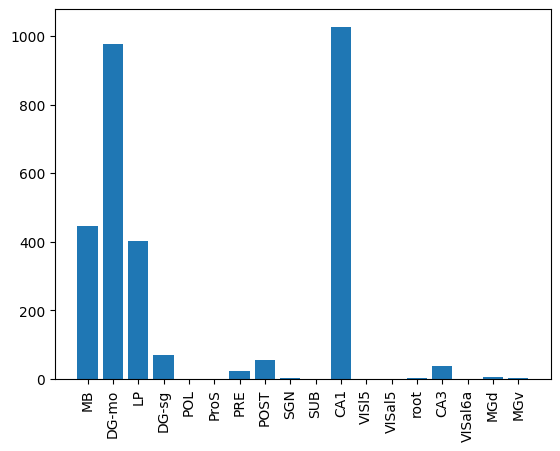

In [55]:
from collections import Counter

locations = [get_unit_location(row) for _, row in units.iterrows()]
counts = Counter(locations)

plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90)
plt.show()


In [56]:
### selecting units spike times

brain_regions = ["SUB", "CA1", "MGd", "DG-mo", "POST", "PRE", "VISl5", "VISal5", "CA3", "SGN", "MB", "VISal6a", "root", "ProS", "MGv", "POL", "DG-sg", "LP"]

# select units based if they have 'good' quality and exists in one of the specified brain_regions
units_spike_times = []
for location in brain_regions:
    location_units_spike_times = []
    for _, row in units.iterrows():
        if get_unit_location(row) == location:
            location_units_spike_times.append(row.spike_times)
    units_spike_times += location_units_spike_times

print(len(units_spike_times))

3057


### Session Timeline
To get a good idea of the order and the way stimulus is shown throughout the session, the code below generates a timeline of the various 'epochs' of stimulus. It can be seen that there are many repeated epochs of the gratings presentation, interspersed with intermission presentations, followed by an epoch of receptive field presentations.

In [57]:
# extract epoch times from stim table where stimulus rows have a different 'block' than following row
# returns list of epochs, where an epoch is of the form (stimulus name, stimulus block, start time, stop time)
def extract_epochs(stim_name, stim_table, epochs):
    
    # specify a current epoch stop and start time
    epoch_start = stim_table.start_time[0]
    epoch_stop = stim_table.stop_time[0]

    # for each row, try to extend current epoch stop_time
    for i in range(len(stim_table)):
        this_block = stim_table.stim_name[i]
        # if end of table, end the current epoch
        if i+1 >= len(stim_table):
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            break
            
        next_block = stim_table.stim_name[i+1]
        # if next row is the same stim block, push back epoch_stop time
        if next_block == this_block:
            epoch_stop = stim_table.stop_time[i+1]
        # otherwise, end the current epoch, start new epoch
        else:
            epochs.append((stim_name, this_block, epoch_start, epoch_stop))
            epoch_start = stim_table.start_time[i+1]
            epoch_stop = stim_table.stop_time[i+1]
    
    return epochs

In [58]:
# extract epochs from all valid stimulus tables
epochs = []
for stim_name in nwb.intervals.keys():
    stim_table = nwb.intervals[stim_name]
    try:
        epochs = extract_epochs(stim_name, stim_table, epochs)
    except:
        continue

# epochs take the form (stimulus name, stimulus block, start time, stop time)
print(len(epochs))
epochs.sort(key=lambda x: x[2])
for epoch in epochs:
    print(epoch)

54
('movie01_presentations', 'movie01', np.float64(82.62420627230888), np.float64(3355.3538162723094))
('movie00_presentations', 'movie00', np.float64(1583.876286272309), np.float64(6387.882966272309))
('movie02_presentations', 'movie02', np.float64(1914.151776272309), np.float64(3385.378866272309))
('movie03_presentations', 'movie03', np.float64(3685.629326272309), np.float64(6988.383766272309))
('movie04_presentations', 'movie04', np.float64(4616.405606272309), np.float64(4646.430696272309))
('movie05_presentations', 'movie05', np.float64(4646.430696272309), np.float64(4676.4557162723095))
('movie06_presentations', 'movie06', np.float64(4676.4557162723095), np.float64(4706.480756272309))
('movie07_presentations', 'movie07', np.float64(4706.480756272309), np.float64(4736.505856272309))
('movie08_presentations', 'movie08', np.float64(4736.505856272309), np.float64(4766.530896272309))
('movie09_presentations', 'movie09', np.float64(4766.530896272309), np.float64(4796.555916272309))
('mo

In [59]:
time_start = floor(min([epoch[2] for epoch in epochs]))
time_end = ceil(max([epoch[3] for epoch in epochs]))
all_units_spike_times = np.concatenate(units_spike_times).ravel()
print(time_start, time_end)

# make histogram of unit spikes per second over specified timeframe
time_bin_edges = np.linspace(time_start, time_end, (time_end-time_start))
hist, bins = np.histogram(all_units_spike_times, bins=time_bin_edges)

82 7475


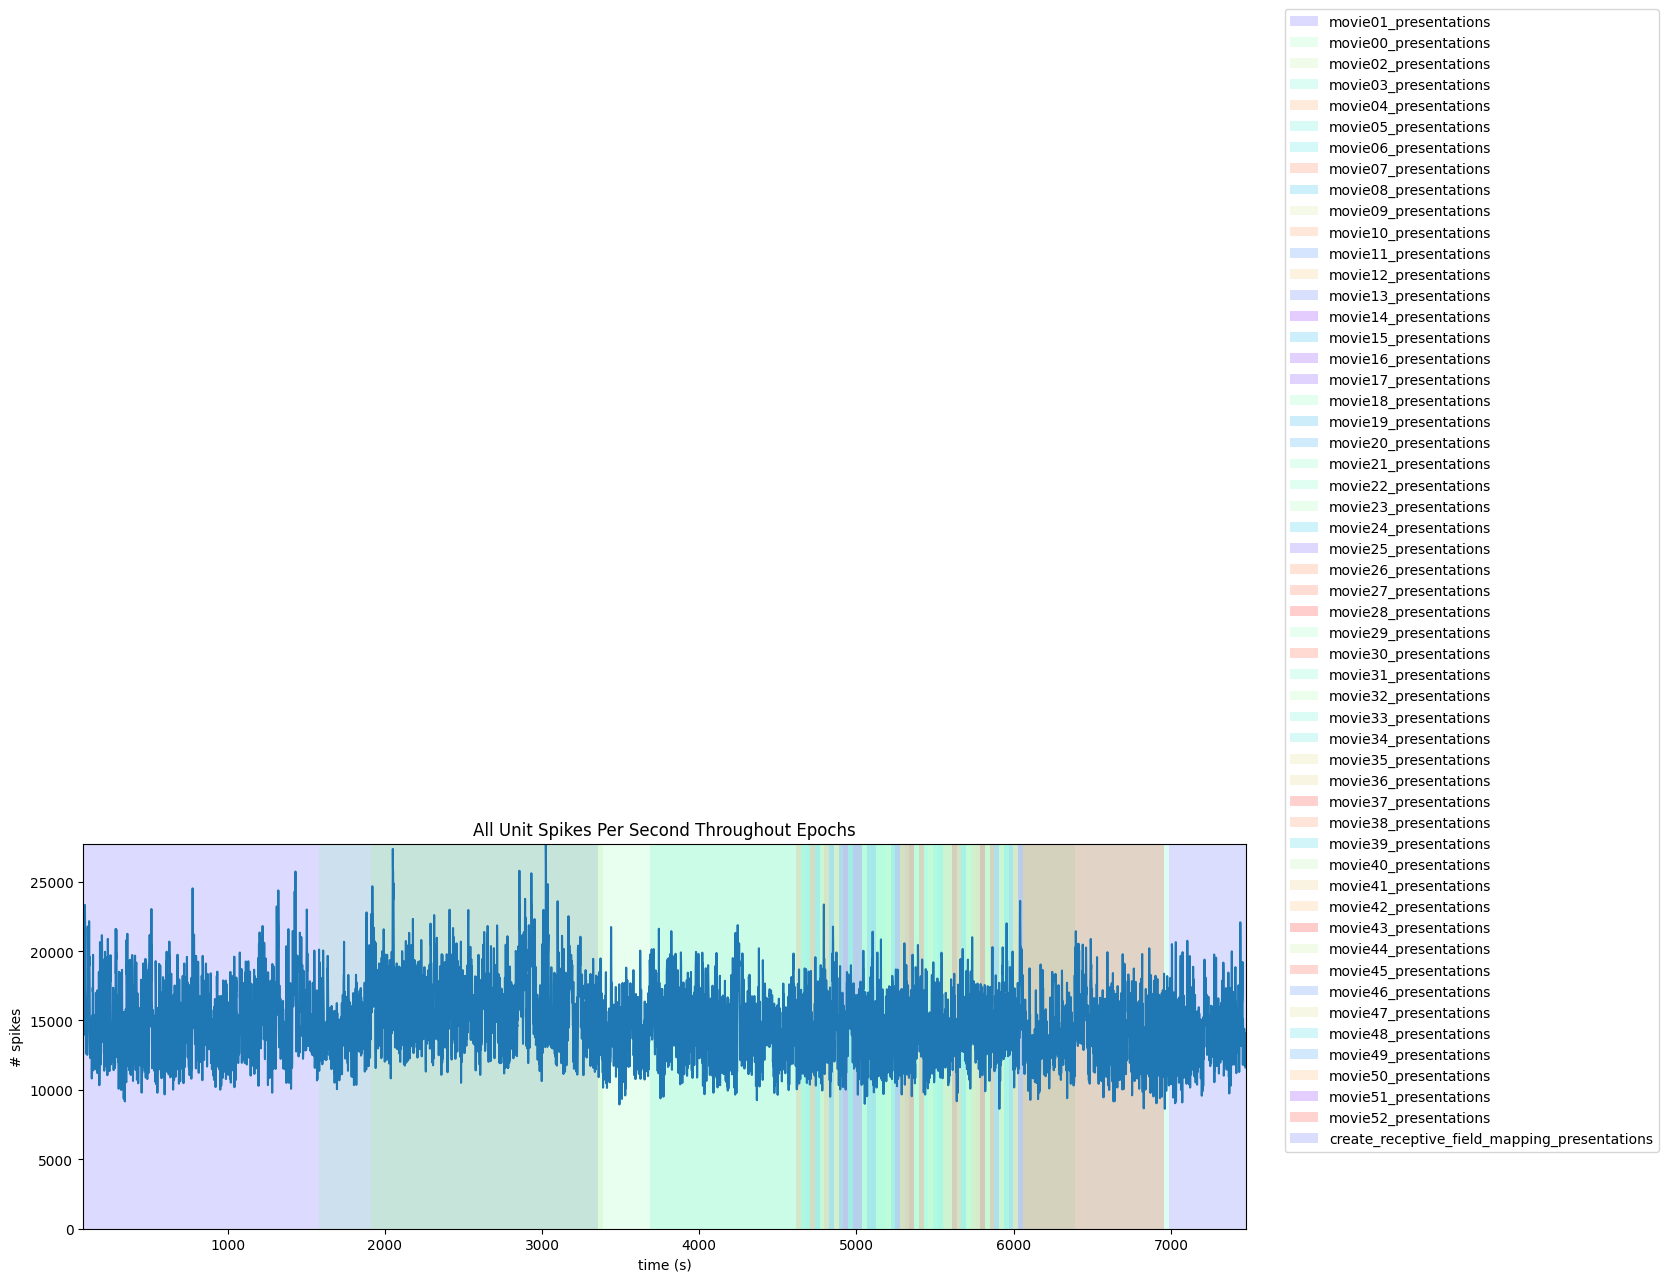

In [60]:
# generate plot of spike histogram with colored epoch intervals and legend
fig, ax = plt.subplots(figsize=(15,5))

# assign unique color to each stimulus name
stim_names = list({epoch[0] for epoch in epochs})
colors = plt.cm.rainbow(np.linspace(0,1,len(stim_names)))
stim_color_map = {stim_names[i]:colors[i] for i in range(len(stim_names))}

epoch_key = {}
height = max(hist)
# draw colored rectangles for each epoch
for epoch in epochs:
    stim_name, stim_block, epoch_start, epoch_end = epoch
    color = stim_color_map[stim_name]
    rec = ax.add_patch(mpl.patches.Rectangle((epoch_start, 0), epoch_end-epoch_start, height, alpha=0.2, facecolor=color))
    epoch_key[stim_name] = rec

ax.set_xlim(time_start, time_end)
ax.set_ylim(-0.1, height+0.1)
ax.set_xlabel("time (s)")
ax.set_ylabel("# spikes")
ax.set_title("All Unit Spikes Per Second Throughout Epochs")

fig.legend(epoch_key.values(), epoch_key.keys(), loc="lower right", bbox_to_anchor=(1.18, 0.25))
ax.plot(bins[:-1], hist)

### Extracting Stimulus Times

In [61]:
nwb.intervals.keys()

dict_keys(['create_receptive_field_mapping_presentations', 'movie00_presentations', 'movie01_presentations', 'movie02_presentations', 'movie03_presentations', 'movie04_presentations', 'movie05_presentations', 'movie06_presentations', 'movie07_presentations', 'movie08_presentations', 'movie09_presentations', 'movie10_presentations', 'movie11_presentations', 'movie12_presentations', 'movie13_presentations', 'movie14_presentations', 'movie15_presentations', 'movie16_presentations', 'movie17_presentations', 'movie18_presentations', 'movie19_presentations', 'movie20_presentations', 'movie21_presentations', 'movie22_presentations', 'movie23_presentations', 'movie24_presentations', 'movie25_presentations', 'movie26_presentations', 'movie27_presentations', 'movie28_presentations', 'movie29_presentations', 'movie30_presentations', 'movie31_presentations', 'movie32_presentations', 'movie33_presentations', 'movie34_presentations', 'movie35_presentations', 'movie36_presentations', 'movie37_present

In [62]:
stim_table = nwb.intervals["movie52_presentations"]
print(np.mean(np.diff(stim_table.start_time)))
print(sorted(set(stim_table.frame)))

0.09099078775078341
['0.0', '1.0', '10.0', '100.0', '101.0', '102.0', '103.0', '104.0', '105.0', '106.0', '107.0', '108.0', '109.0', '11.0', '110.0', '111.0', '112.0', '113.0', '114.0', '115.0', '116.0', '117.0', '118.0', '119.0', '12.0', '120.0', '121.0', '122.0', '123.0', '124.0', '125.0', '126.0', '127.0', '128.0', '129.0', '13.0', '130.0', '131.0', '132.0', '133.0', '134.0', '135.0', '136.0', '137.0', '138.0', '139.0', '14.0', '140.0', '141.0', '142.0', '143.0', '144.0', '145.0', '146.0', '147.0', '148.0', '149.0', '15.0', '150.0', '151.0', '152.0', '153.0', '154.0', '155.0', '156.0', '157.0', '158.0', '159.0', '16.0', '160.0', '161.0', '162.0', '163.0', '164.0', '165.0', '166.0', '167.0', '168.0', '169.0', '17.0', '170.0', '171.0', '172.0', '173.0', '174.0', '175.0', '176.0', '177.0', '178.0', '179.0', '18.0', '180.0', '181.0', '182.0', '183.0', '184.0', '185.0', '186.0', '187.0', '188.0', '189.0', '19.0', '190.0', '191.0', '192.0', '193.0', '194.0', '195.0', '196.0', '197.0', '19

In [63]:
# select times where im036_r was displayed
selected_stim_times = [stim_table[i].start_time.item() for i in range(len(stim_table)) if stim_table.frame[i] == "0.0"]
print(len(selected_stim_times))

11


### Generating Spike Matrix

In [64]:
# bin size for counting spikes
time_resolution = 0.005

# start and end times (relative to the stimulus at 0 seconds) that we want to examine and align spikes to
window_start_time = -0.25
window_end_time = 0.5

In [65]:
def get_spike_matrix(stim_times, units_spike_times, bin_edges):
    time_resolution = np.mean(np.diff(bin_edges))
    # 3D spike matrix to be populated with spike counts
    spike_matrix = np.zeros((len(units_spike_times), len(stim_times), len(bin_edges)-1))

    # populate 3D spike matrix for each unit for each stimulus trial by counting spikes into bins
    for unit_idx in range(len(units_spike_times)):
        spike_times = units_spike_times[unit_idx]

        for stim_idx, stim_time in enumerate(stim_times):
            # get spike times that fall within the bin's time range relative to the stim time        
            first_bin_time = stim_time + bin_edges[0]
            last_bin_time = stim_time + bin_edges[-1]
            first_spike_in_range, last_spike_in_range = np.searchsorted(spike_times, [first_bin_time, last_bin_time])
            spike_times_in_range = spike_times[first_spike_in_range:last_spike_in_range]

            # convert spike times into relative time bin indices
            bin_indices = ((spike_times_in_range - (first_bin_time)) / time_resolution).astype(int)
            
            # mark that there is a spike at these bin times for this unit on this stim trial
            for bin_idx in bin_indices:
                spike_matrix[unit_idx, stim_idx, bin_idx] += 1

    return spike_matrix

In [66]:
# time bins used
n_bins = int((window_end_time - window_start_time) / time_resolution)
bin_edges = np.linspace(window_start_time, window_end_time, n_bins, endpoint=True)

# calculate baseline and stimulus interval indices for use later
stimulus_onset_idx = int(-bin_edges[0] / time_resolution)

spike_matrix = get_spike_matrix(selected_stim_times, units_spike_times, bin_edges)

print(spike_matrix.shape)

(3057, 11, 149)


### Showing Response Windows
After generating spike matrices, we can view the PSTHs for each unit.

In [67]:
def show_response(ax, window, window_start_time, window_end_time, aspect="auto", vmin=None, vmax=None, yticklabels=[], skipticks=1, xlabel="Time (s)", ylabel="ROI", cbar=True, cbar_label=None):
    if len(window) == 0:
        print("Input data has length 0; Nothing to display")
        return

    img = ax.imshow(window, aspect=aspect, extent=[window_start_time, window_end_time, 0, len(window)], interpolation="none", vmin=vmin, vmax=vmax)
    if cbar:
        ax.colorbar(img, shrink=0.5, label=cbar_label)

    ax.plot([0,0],[0, len(window)], ":", color="white", linewidth=1.0)

    if len(yticklabels) != 0:
        ax.set_yticks(range(len(yticklabels)))
        ax.set_yticklabels(yticklabels, fontsize=8)

        n_ticks = len(yticklabels[::skipticks])
        ax.yaxis.set_major_locator(plt.MaxNLocator(n_ticks))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

In [68]:
def show_many_responses(windows, rows, cols, window_idxs=None, title=None, subplot_title="", xlabel=None, ylabel=None, cbar_label=None, vmin=0, vmax=2):
    if window_idxs is None:
        window_idxs = range(len(windows))
    windows = windows[window_idxs]
    
    # handle case with no input data
    if len(windows) == 0:
        print("Input data has length 0; Nothing to display")
        return
    # handle cases when there aren't enough windows for number of rows
    if len(windows) < rows*cols:
        rows = (len(windows) // cols) + 1

    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 3*rows), layout="constrained")
    # handle case when there's only one row
    if len(axes.shape) == 1:
        axes = axes.reshape((1, axes.shape[0]))

    for i in range(rows*cols):
        ax_row = int(i // cols)
        ax_col = i % cols
        ax = axes[ax_row][ax_col]
        
        if i > len(windows)-1:
            ax.set_visible(False)
            continue

        window = windows[i]
        show_response(ax, window, window_start_time, window_end_time, xlabel=xlabel, ylabel=ylabel, cbar=False, vmin=vmin, vmax=vmax)
        ax.set_title(f"{subplot_title} {window_idxs[i]}")
        if ax_row != rows-1:
            ax.get_xaxis().set_visible(False)
        if ax_col != 0:
            ax.get_yaxis().set_visible(False)

    fig.suptitle(title)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm), ax=axes, shrink=2/cols, label=cbar_label)
    plt.show()


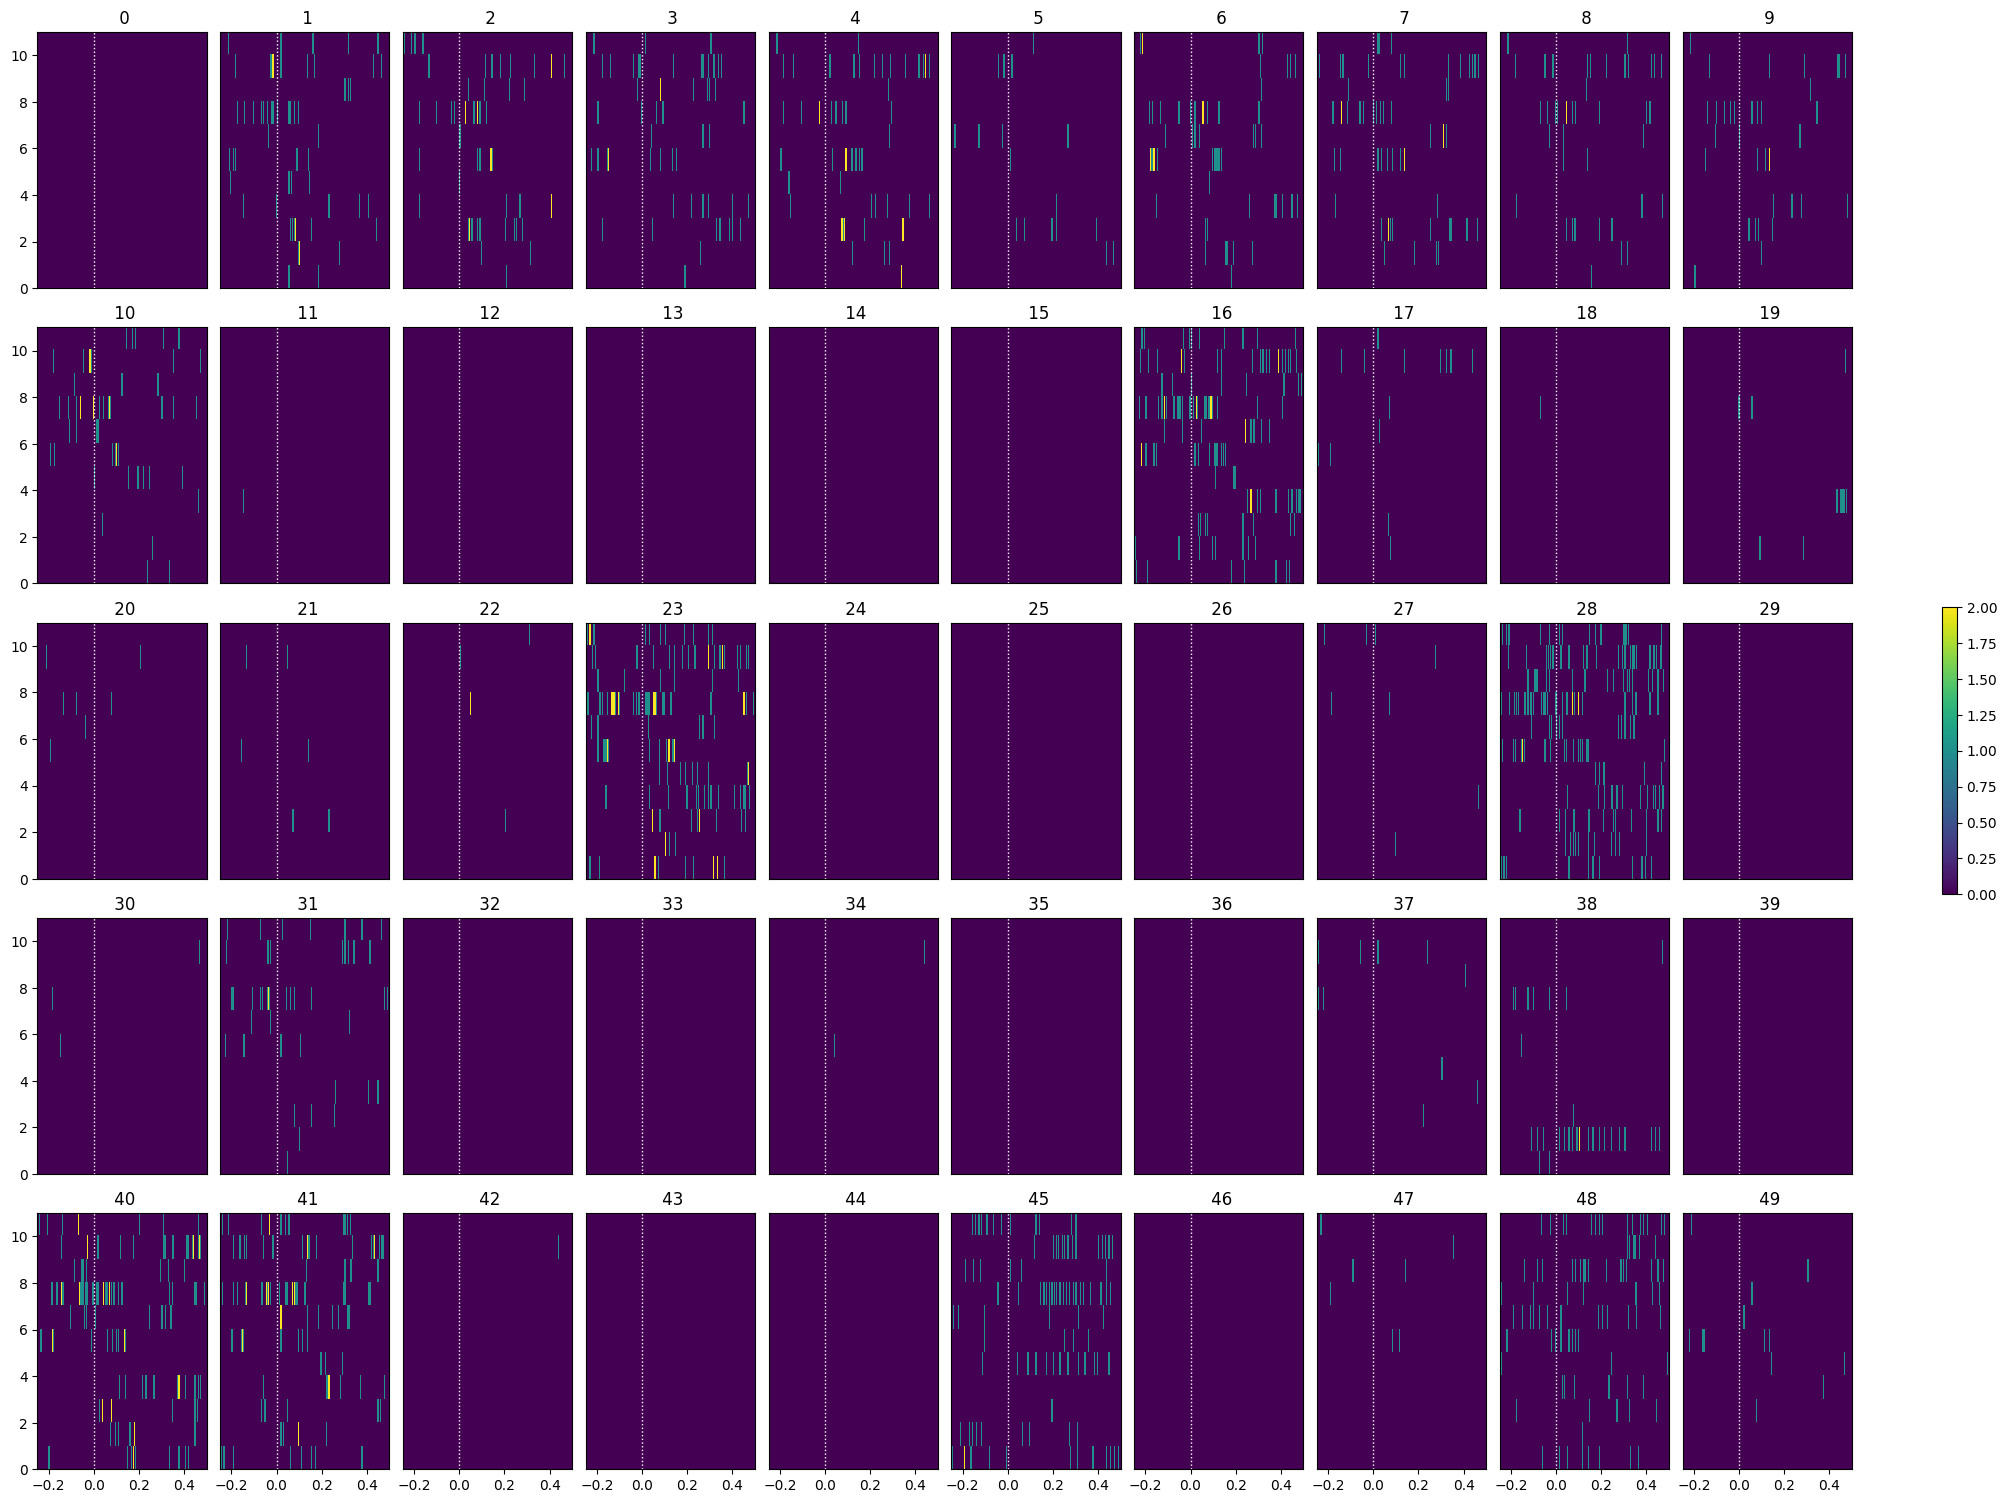

In [69]:
show_many_responses(spike_matrix, 5, 10)

### Selecting Responsive Cells
As discussed in [Statistically Testing 2P Responses to Stimulus](../first-order/test_2p_responses.ipynb), the criteria used to select for responsive cells can have a significant impact. Here, the simple criterion is to select units whose post-stimulus z-scores are greater than 1 or less than -1.

In [70]:
def select_cells(spike_matrix, stimulus_onset_idx):
    baseline_means = np.mean(spike_matrix[:,:,:stimulus_onset_idx], axis=2)
    mean_baseline_means = np.mean(baseline_means, axis=1)
    std_baseline_means = np.std(baseline_means, axis=1)

    response_means = np.mean(spike_matrix[:,:,stimulus_onset_idx:], axis=2)
    mean_response_means = np.mean(response_means, axis=1)

    unit_z_scores = (mean_response_means - mean_baseline_means) / std_baseline_means
    return np.where(np.logical_or(unit_z_scores > 1, unit_z_scores < -1))[0]

C:\Users\carter.peene\AppData\Local\Temp\ipykernel_2800\1852969462.py:9: RuntimeWarning: divide by zero encountered in divide
  unit_z_scores = (mean_response_means - mean_baseline_means) / std_baseline_means
C:\Users\carter.peene\AppData\Local\Temp\ipykernel_2800\1852969462.py:9: RuntimeWarning: invalid value encountered in divide
  unit_z_scores = (mean_response_means - mean_baseline_means) / std_baseline_means


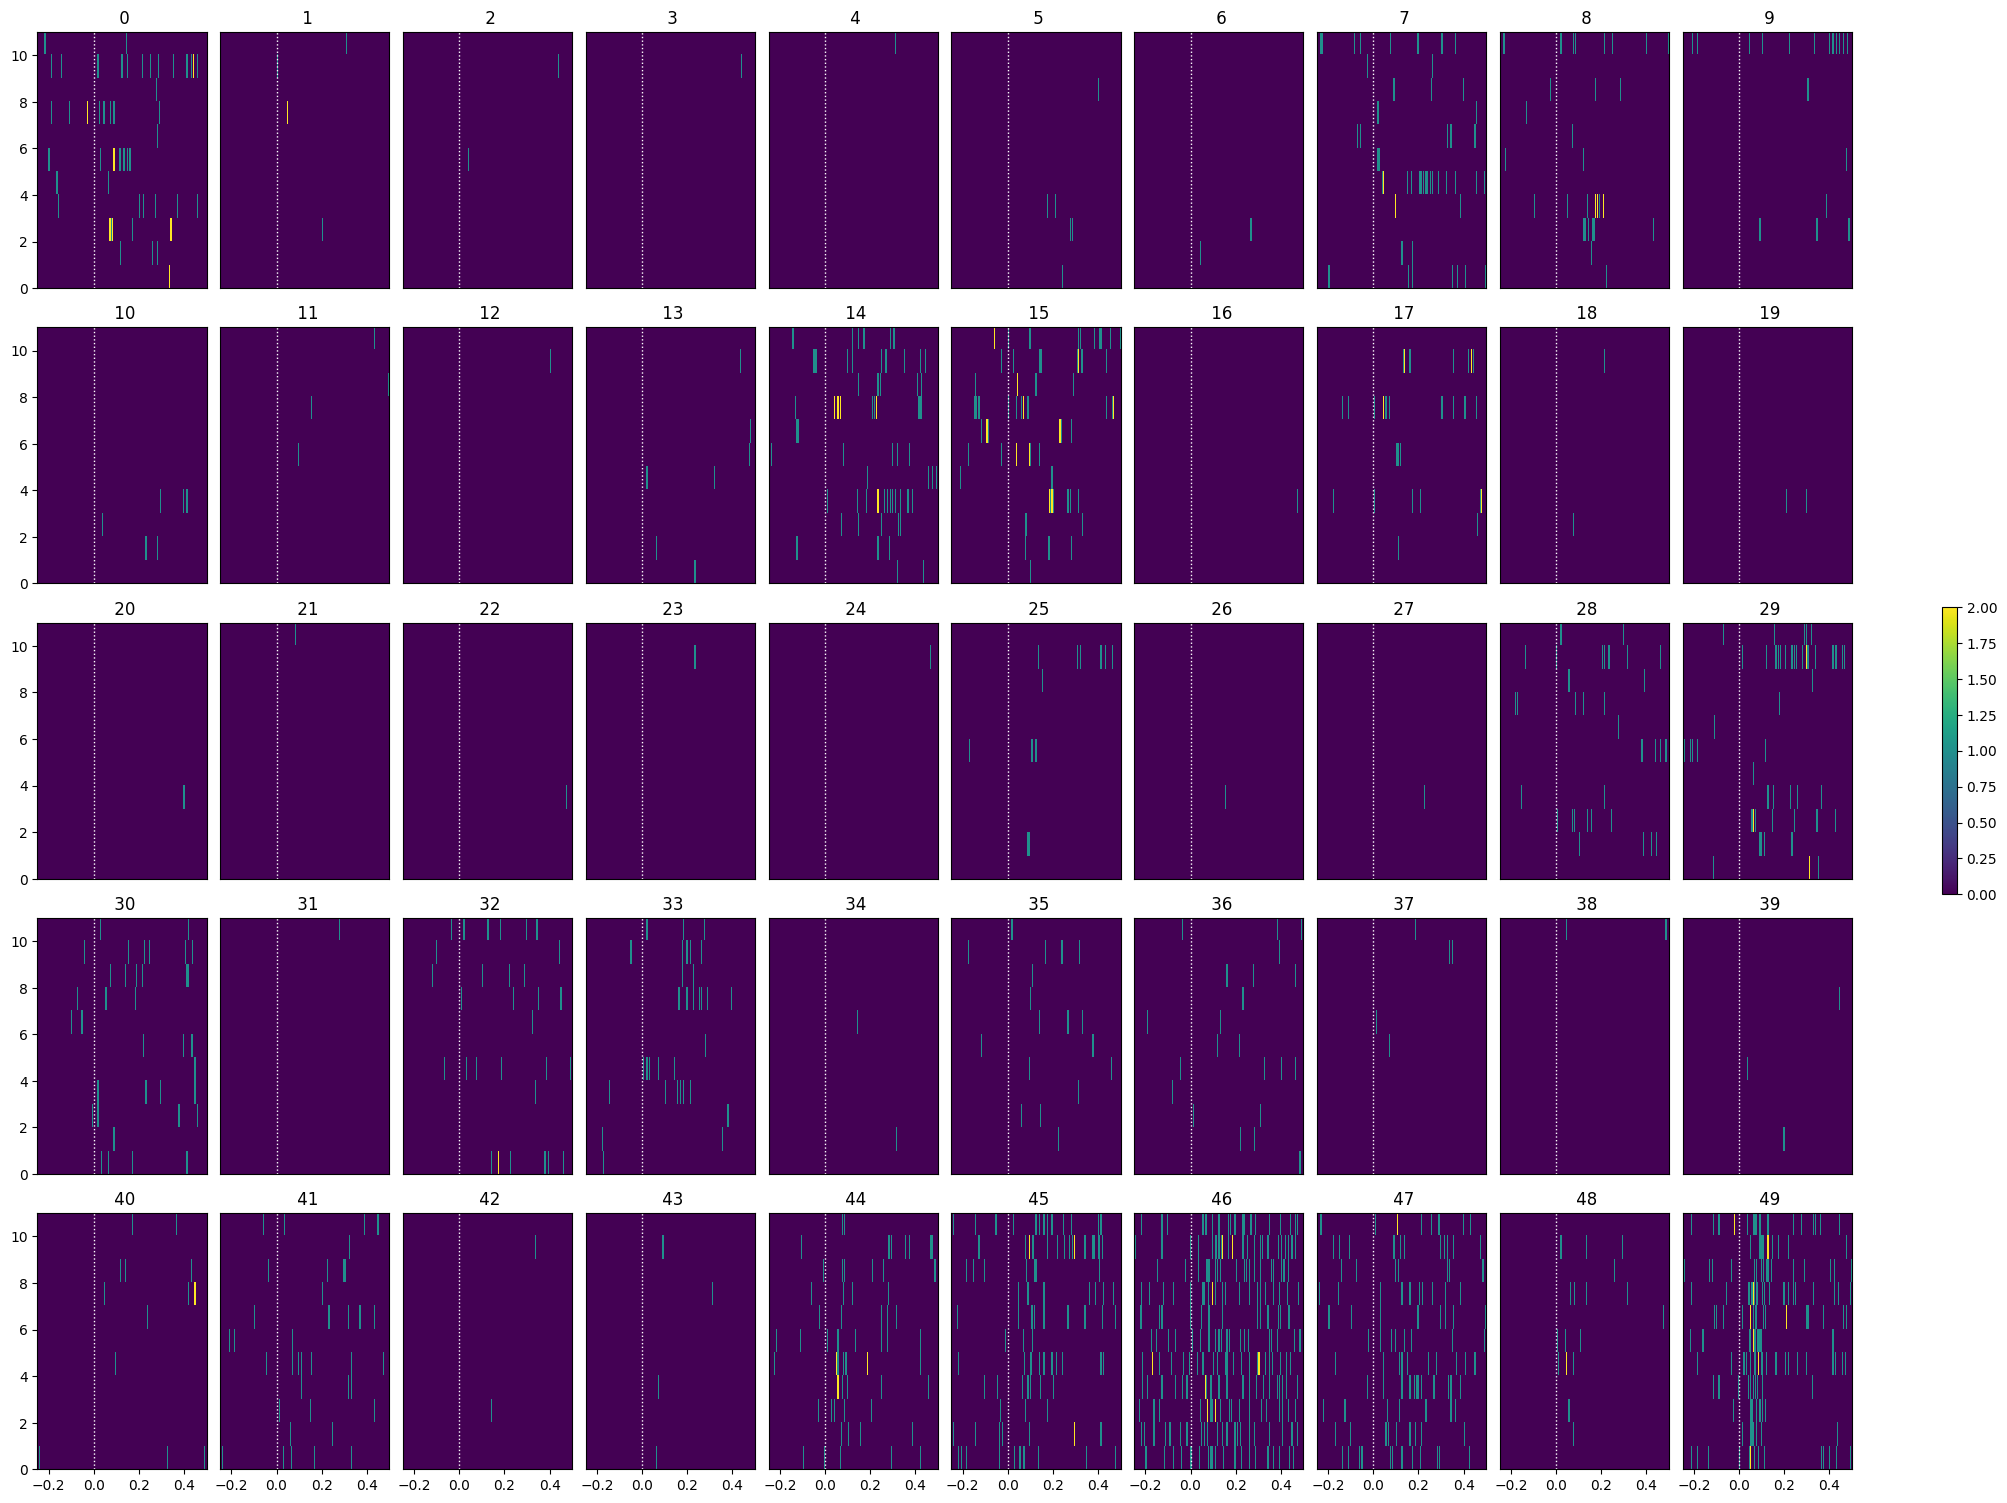

In [71]:
selected_idxs = select_cells(spike_matrix, stimulus_onset_idx)
show_many_responses(spike_matrix[selected_idxs], 5, 10)